In [1]:
# importing required libraries

import pandas as pd
import numpy as np

In [2]:
# loading the dataset

df = pd.read_csv("Maternal Health Risk Data Set.csv")

# checking dataset size
print(df.shape)

# seeing first few rows
print(df.head())

(1014, 7)
   Age  SystolicBP  DiastolicBP    BS  BodyTemp  HeartRate  RiskLevel
0   25         130           80  15.0      98.0         86  high risk
1   35         140           90  13.0      98.0         70  high risk
2   29          90           70   8.0     100.0         80  high risk
3   30         140           85   7.0      98.0         70  high risk
4   35         120           60   6.1      98.0         76   low risk


In [3]:
# removing extra spaces from column names

df.columns = df.columns.str.strip()

print(df.columns)

Index(['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate',
       'RiskLevel'],
      dtype='object')


In [4]:
# removing duplicate rows if any

rows_before = df.shape[0]

df = df.drop_duplicates()

rows_after = df.shape[0]

print("Duplicates removed:", rows_before - rows_after)

Duplicates removed: 562


In [5]:
# making risk labels consistent

df["RiskLevel"] = df["RiskLevel"].str.strip().str.lower()

print(df["RiskLevel"].value_counts())

RiskLevel
low risk     234
high risk    112
mid risk     106
Name: count, dtype: int64


In [6]:
# making sure all health values are numeric

num_cols = ["Age", "SystolicBP", "DiastolicBP", "BS", "BodyTemp", "HeartRate"]

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print(df.dtypes)

Age              int64
SystolicBP       int64
DiastolicBP      int64
BS             float64
BodyTemp       float64
HeartRate        int64
RiskLevel       object
dtype: object


In [7]:
# checking if any missing values are present

print(df.isnull().sum())

Age            0
SystolicBP     0
DiastolicBP    0
BS             0
BodyTemp       0
HeartRate      0
RiskLevel      0
dtype: int64


In [8]:
# limiting extreme values using IQR method

for col in num_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

print("Outliers handled")

Outliers handled


In [9]:
# final dataset check

print(df.shape)
print(df["RiskLevel"].value_counts())
print(df.describe())

(452, 7)
RiskLevel
low risk     234
high risk    112
mid risk     106
Name: count, dtype: int64
              Age  SystolicBP  DiastolicBP          BS  BodyTemp  HeartRate
count  452.000000  452.000000   452.000000  452.000000     452.0  452.00000
mean    29.064159  110.553097    75.418142    7.579358      98.0   74.05531
std     13.454295   17.872282    13.754578    0.961964       0.0    7.57514
min     10.000000   70.000000    49.000000    6.000000      98.0   55.00000
25%     19.000000   90.000000    65.000000    6.900000      98.0   70.00000
50%     25.000000  120.000000    80.000000    7.500000      98.0   76.00000
75%     35.000000  120.000000    86.000000    7.900000      98.0   80.00000
max     59.000000  160.000000   100.000000    9.400000      98.0   90.00000


In [10]:
# importing libraries for visualization

import matplotlib.pyplot as plt
import seaborn as sns

# basic statistical summary

print(df.describe())

# checking class distribution
print(df["RiskLevel"].value_counts())

              Age  SystolicBP  DiastolicBP          BS  BodyTemp  HeartRate
count  452.000000  452.000000   452.000000  452.000000     452.0  452.00000
mean    29.064159  110.553097    75.418142    7.579358      98.0   74.05531
std     13.454295   17.872282    13.754578    0.961964       0.0    7.57514
min     10.000000   70.000000    49.000000    6.000000      98.0   55.00000
25%     19.000000   90.000000    65.000000    6.900000      98.0   70.00000
50%     25.000000  120.000000    80.000000    7.500000      98.0   76.00000
75%     35.000000  120.000000    86.000000    7.900000      98.0   80.00000
max     59.000000  160.000000   100.000000    9.400000      98.0   90.00000
RiskLevel
low risk     234
high risk    112
mid risk     106
Name: count, dtype: int64


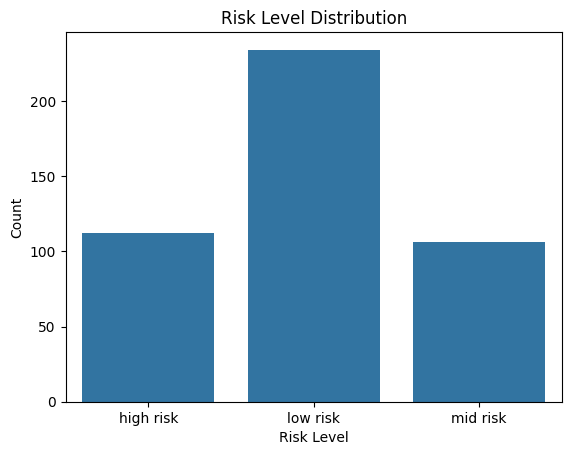

In [11]:
# count plot for risk levels

plt.figure()
sns.countplot(x="RiskLevel", data=df)
plt.title("Risk Level Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Count")
plt.show()

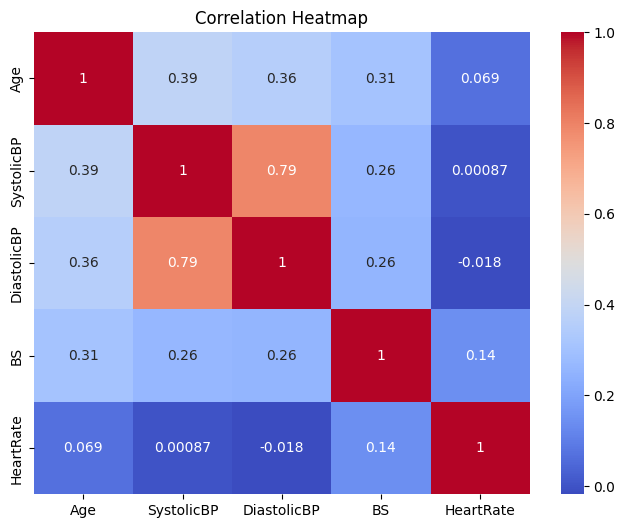

In [12]:
# ---- Correlation Heatmap ----

plt.figure(figsize=(8,6))

# take only numeric columns
num_df = df.select_dtypes(include=["int64","float64"])

# remove columns which have only one unique value
# (constant columns like BodyTemp)
num_df = num_df.loc[:, num_df.nunique() > 1]

# calculate correlation
corr = num_df.corr()

# plot heatmap
sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

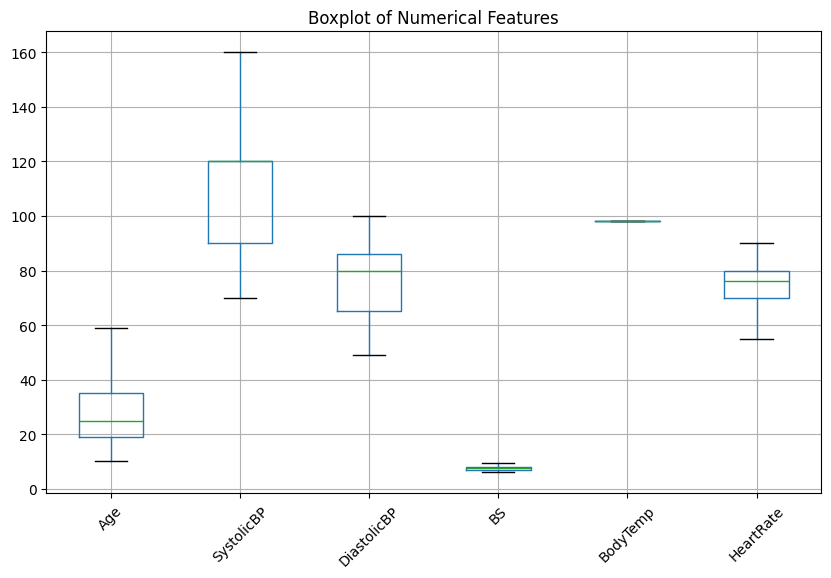

In [13]:
# boxplot for all numeric features

plt.figure(figsize=(10,6))

df.boxplot()

plt.title("Boxplot of Numerical Features")
plt.xticks(rotation=45)
plt.show()

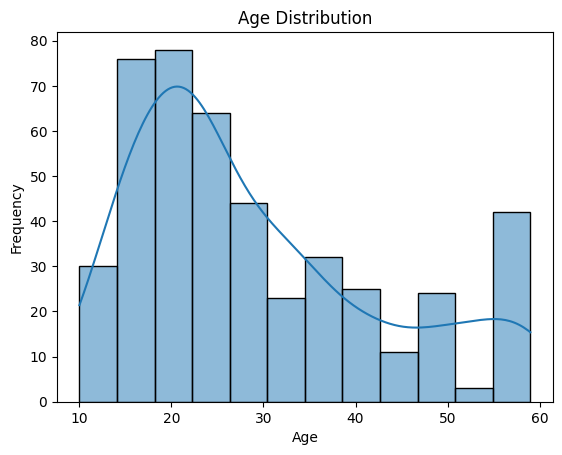

In [14]:
# distribution of Age

plt.figure()

sns.histplot(df["Age"], kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

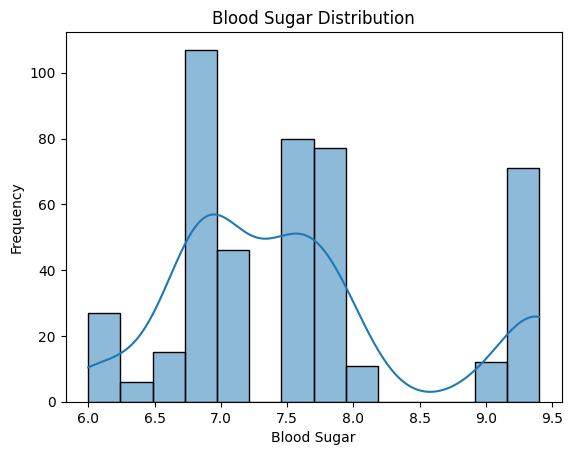

In [15]:
# distribution of Blood Sugar

plt.figure()

sns.histplot(df["BS"], kde=True)

plt.title("Blood Sugar Distribution")
plt.xlabel("Blood Sugar")
plt.ylabel("Frequency")
plt.show()